First importing all the right packages

In [30]:
import mne
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline 

In [31]:
vhdr_path = Path("/work/EEG_lab/own_experiments_data/group14_own_2.vhdr")

raw = mne.io.read_raw_brainvision("/work/EEG_lab/own_experiments_data/group14_own_2.vhdr", eog=("HEOG", "VEOG"))

raw.load_data()

Extracting parameters from /work/EEG_lab/own_experiments_data/group14_own_2.vhdr...
Setting channel info structure...
Reading 0 ... 545719  =      0.000 ...   545.719 secs...


<RawBrainVision | group14_own_2.eeg, 32 x 545720 (545.7 s), ~133.3 MiB, data loaded>

c. Specify the channel locations using the montage-related functions:
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, verbose=False)

In [32]:
vhdr_path = Path("/work/EEG_lab/own_experiments_data/group14_own_2.vhdr")

raw = mne.io.read_raw_brainvision("/work/EEG_lab/own_experiments_data/group14_own_2.vhdr", eog=("HEOG", "VEOG"))
montage = mne.channels.make_standard_montage('standard_1020')

raw.load_data()

raw.set_montage(montage, verbose=False) 

Extracting parameters from /work/EEG_lab/own_experiments_data/group14_own_2.vhdr...
Setting channel info structure...
Reading 0 ... 545719  =      0.000 ...   545.719 secs...


<RawBrainVision | group14_own_2.eeg, 32 x 545720 (545.7 s), ~133.3 MiB, data loaded>

In [33]:
raw.set_eeg_reference('average', projection=False, verbose=False)

<RawBrainVision | group14_own_2.eeg, 32 x 545720 (545.7 s), ~133.3 MiB, data loaded>

Plotting it


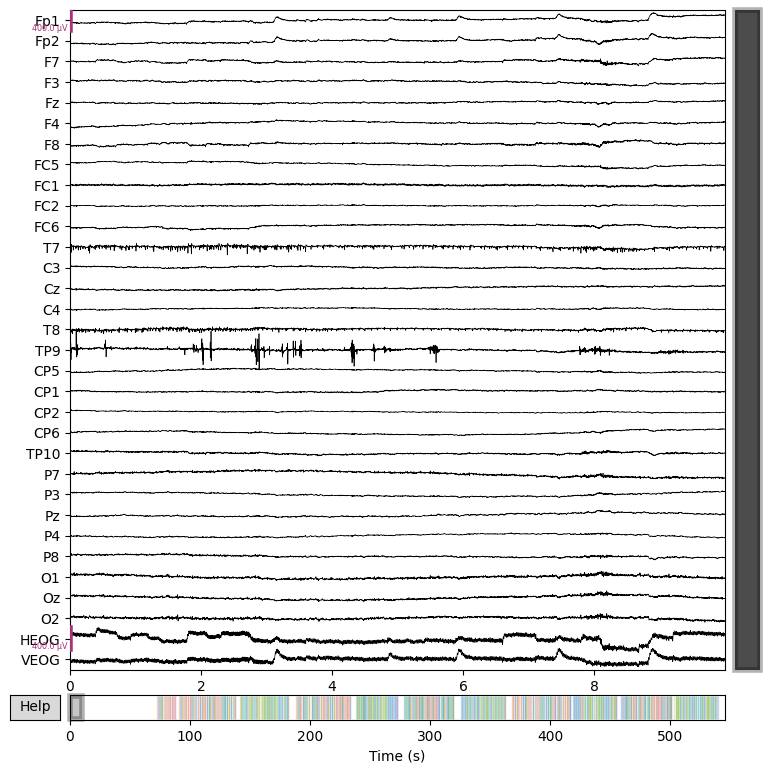

In [34]:
raw.plot(n_channels=len(raw.ch_names), scalings=200e-6); 

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 33001 samples (33.001 s)



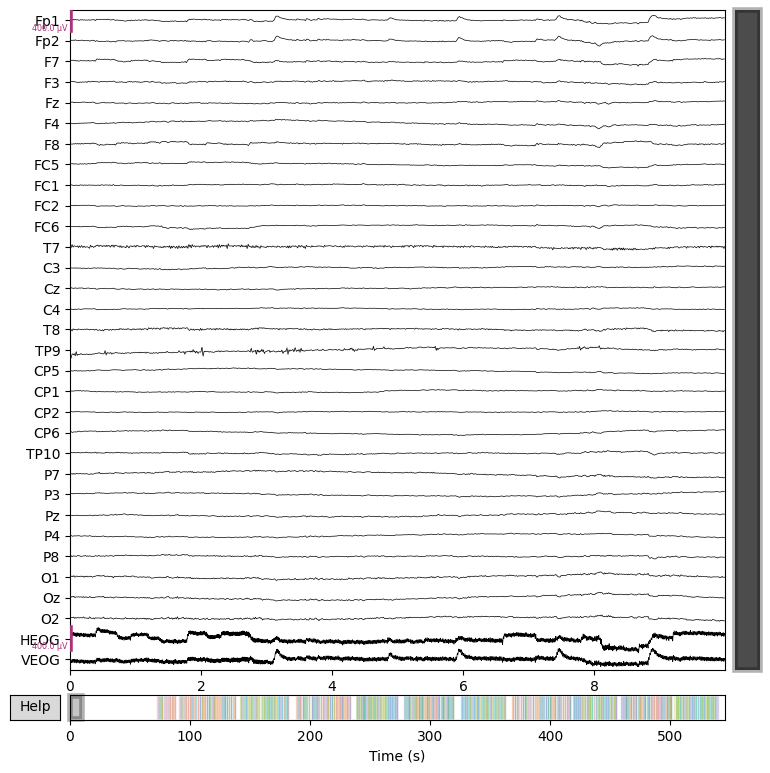

In [35]:
raw.filter(l_freq=0.1, h_freq=40.0)
raw.plot(n_channels=len(raw.ch_names), scalings=200e-6); 

In [36]:

events = mne.events_from_annotations(raw, verbose=False)
events, _ = mne.events_from_annotations(raw, verbose=False)
print(events)

[[ 72112      0      3]
 [ 73601      0      5]
 [ 74081      0      2]
 ...
 [538529      0      5]
 [538999      0     13]
 [539662      0      5]]


In [37]:
np.unique(events[:,2]) 

array([ 2,  3,  4,  5,  6,  7,  8, 12, 13])

In [38]:

event_id = { 'Liv/norm': 2,
'Nonliv/norm': 3,
'Resp/left': 4,
'Resp/right': 5,
'Slow': 6, 
'Block/norm': 7,
'Block/speed': 8,
'Liv/speed': 12, 
'Nonliv/speed': 13,
}


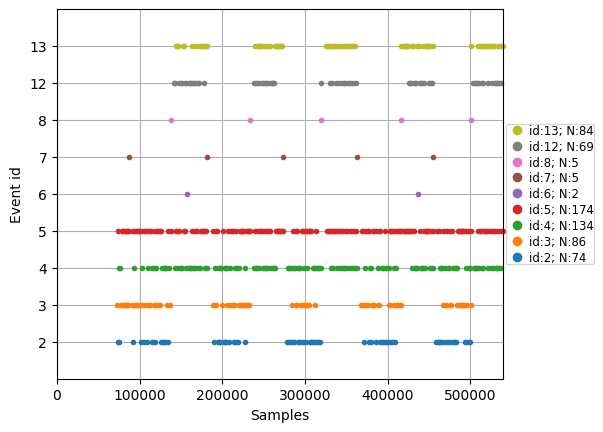

In [39]:
mne.viz.plot_events(events); 

In [40]:
epochs = mne.Epochs( 
    raw, 
    events,
    event_id=event_id, 
    tmin = -0.1, 
    tmax = 0.7, 
    reject = {'eeg': 150e-6},
    picks = ['eeg'],
    baseline = (-0.1, 0), 
    preload = True
) 


Not setting metadata
633 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 633 events and 801 original time points ...
    Rejecting  epoch based on EEG : ['TP10']
    Rejecting  epoch based on EEG : ['T7']
    Rejecting  epoch based on EEG : ['T7', 'TP10']
    Rejecting  epoch based on EEG : ['T7', 'TP10']
    Rejecting  epoch based on EEG : ['T7', 'TP10']
    Rejecting  epoch based on EEG : ['O1']
    Rejecting  epoch based on EEG : ['O1']
    Rejecting  epoch based on EEG : ['O1']
    Rejecting  epoch based on EEG : ['T7']
    Rejecting  epoch based on EEG : ['T7', 'TP10']
    Rejecting  epoch based on EEG : ['TP9']
    Rejecting  epoch based on EEG : ['FC1']
    Rejecting  epoch based on EEG : ['FC1']
    Rejecting  epoch based on EEG : ['FC1']
    Rejecting  epoch based on EEG : ['FC1']
    Rejecting  epoch based on EEG : ['FC1']
    Rejecting  epoch based on EEG : ['T7']
    Rejecting  epoch based on EEG

In [41]:
epochs.resample(250)

<Epochs | 614 events (all good), -0.1 – 0.696 s (baseline -0.1 – 0 s), ~28.1 MiB, data loaded,
 'Liv/norm': 74
 'Nonliv/norm': 84
 'Resp/left': 130
 'Resp/right': 169
 'Slow': 2
 'Block/norm': 5
 'Block/speed': 4
 'Liv/speed': 65
 'Nonliv/speed': 81>

Not setting metadata
84 matching events found
No baseline correction applied
0 projection items activated


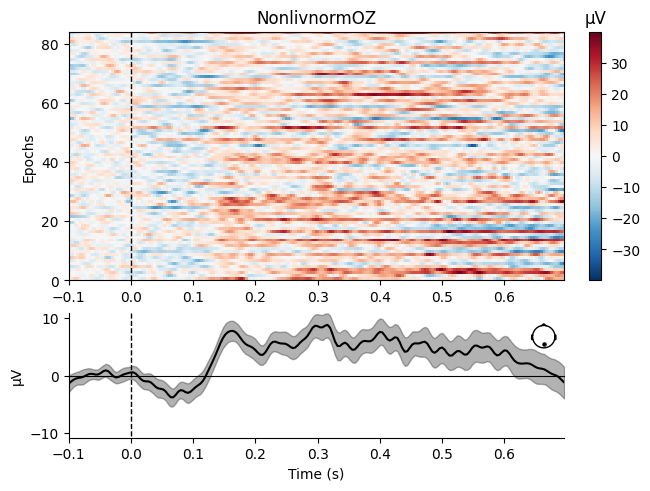

Not setting metadata
4 matching events found
No baseline correction applied
0 projection items activated


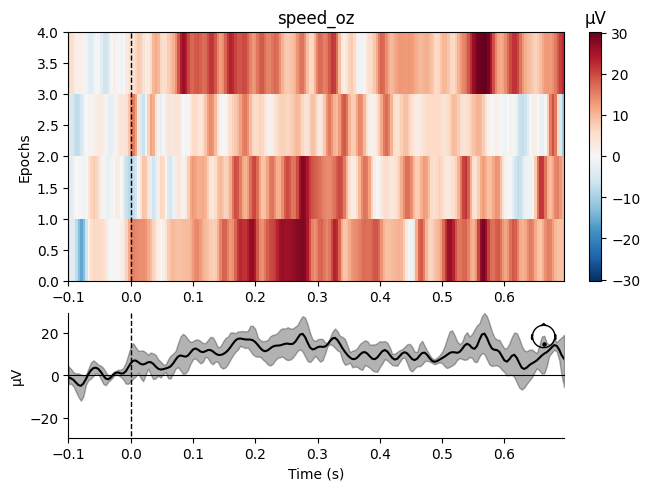

Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated


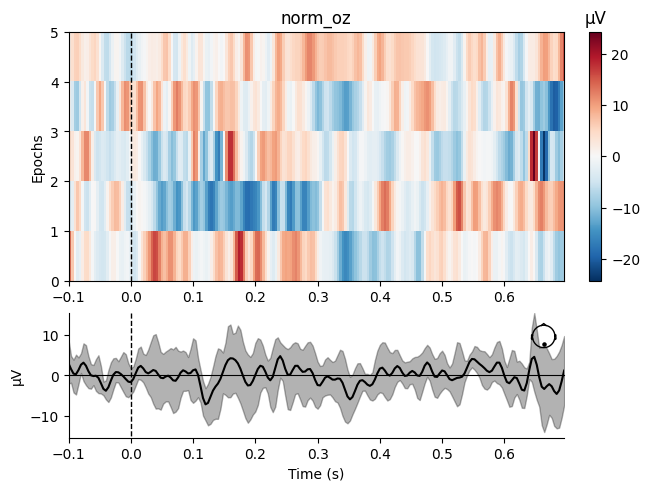

[<Figure size 640x480 with 4 Axes>]

In [42]:
epochs_nonlivnorm = epochs['Nonliv/norm']
epochs_speed = epochs['Block/speed']
epochs_norm = epochs['Block/norm']

epochs_nonlivnorm.plot_image(picks='Oz', title="NonlivnormOZ")
epochs_speed.plot_image(picks='Oz', title="speed_oz")

epochs_norm.plot_image(picks='Oz', title="norm_oz")


This is the analysis part. We will start with some logistic regression code

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler 
from sklearn.pipeline import Pipeline 
from sklearn.model_selection import cross_val_score, StratifiedKFold


In [44]:
#first we have to epoch based on the blocks - this is done like in the tutorials 
epochs_speed = epochs['Block/speed']
epochs_norm = epochs['Block/norm']





#then, we have to extract the data and build the labels - this can be seen when we run the code
X_speed = epochs_speed.get_data
X_norm  = epochs_norm.get_data() 
#the shape of these are: (n_epochs, n_channels, n_timepoints)

Because the epoch data is 3D, we need to make it into 2D so that sklearn can process it. This is done by flattening channels x timepoints into a single-feature vector pr. epoch. Meaning the 2D vector will look like this:

In [46]:
X_speed = epochs_speed.get_data()  
X_norm  = epochs_norm.get_data()

X_speed_2d = X_speed.reshape(len(X_speed), -1)  # (n_epochs, n_ch * n_times)
X_norm_2d  = X_norm.reshape(len(X_norm),  -1)

# Stack into one matrix, create labels(1 = speed, 0 = normal)
X = np.vstack([X_speed_2d, X_norm_2d])
y = np.array([1] * len(X_speed) + [0] * len(X_norm))

Now we can simply build the scaler+classifier, which is going to be our pipeline. This is very standard for when using logistic regression

In [ ]:
print(epochs_speed.event_id)       # named event labels
print(epochs_speed.metadata)       # metadata table (may be None)
print(epochs_speed.events[:5, 2])  # raw event IDs

{'Block/speed': 8}
None
[8 8 8 8]


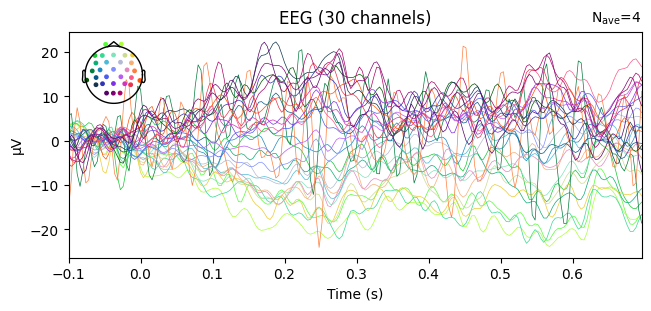

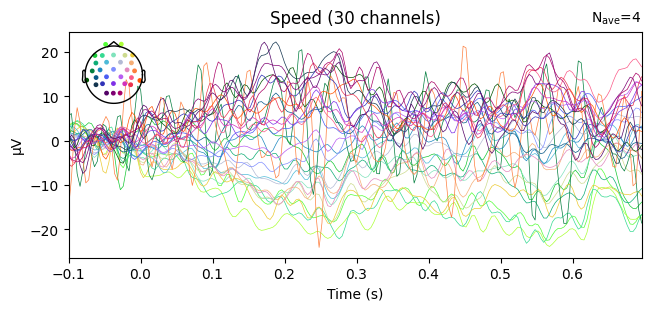

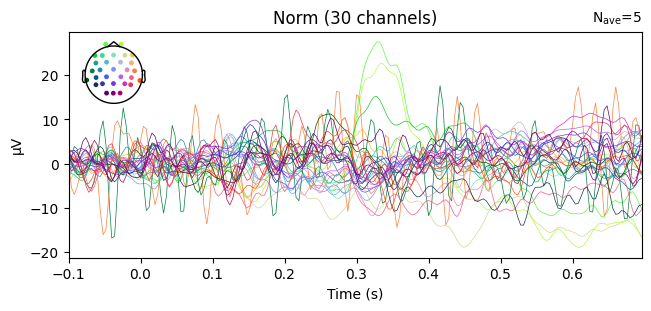

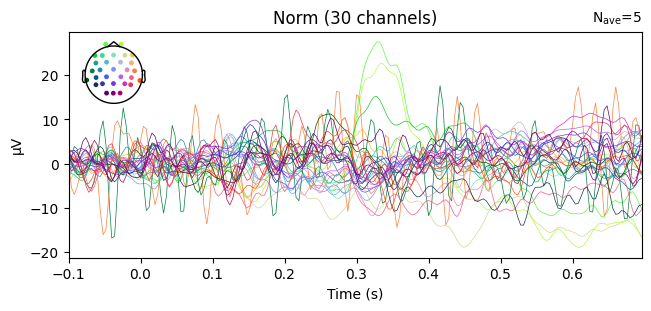

In [50]:
epochs_speed = epochs['Block/speed']
epochs_norm = epochs['Block/norm']

speed = epochs['Block/speed']
speed_evoked = speed.average()

normal = epochs['Block/norm']
normal_evoked = normal.average()

speed_evoked.plot()

speed_evoked.plot(picks='eeg', spatial_colors=True, titles='Speed')
normal_evoked.plot(picks='eeg', spatial_colors=True, titles='Norm')




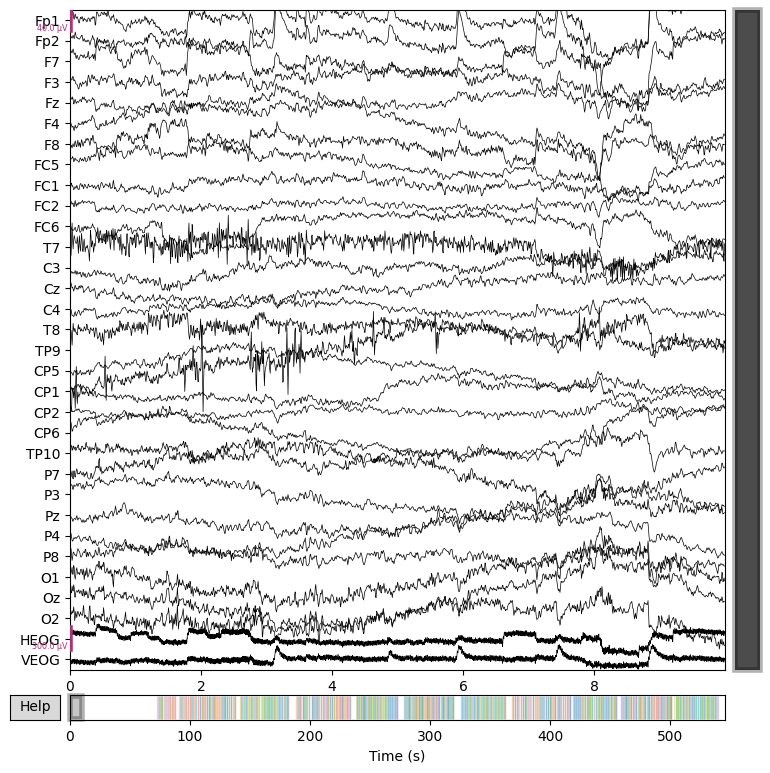

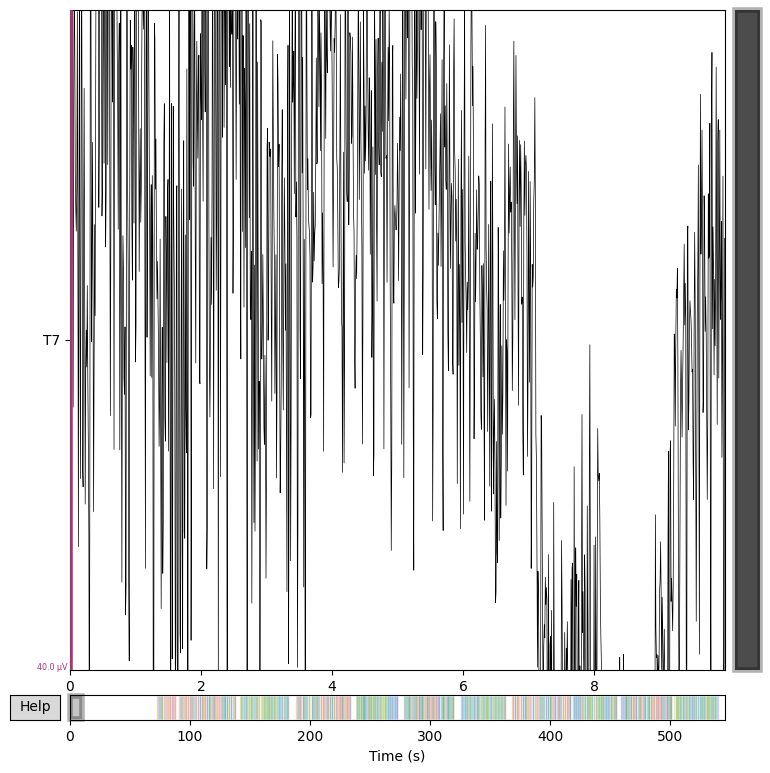

T7 variance after interpolation: 0.0000
Mean variance across all channels: 0.0000


In [51]:

raw.plot(duration=10, n_channels=64)

raw.plot(picks=['T7'], duration=10)

t7_idx = raw.ch_names.index('T7')
t7_data = raw.get_data(picks=['T7'])
print(f"T7 variance after interpolation: {t7_data.var():.4f}")
print(f"Mean variance across all channels: {raw.get_data().var(axis=1).mean():.4f}")

In [53]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import balanced_accuracy_score
import mne

#dropping noisy channels before epoch
DROP_CH = ['T7', 'T8']
raw.drop_channels([ch for ch in DROP_CH if ch in raw.ch_names])


events_orig, _ = mne.events_from_annotations(raw, verbose=False)

#epoch all events
epochs_speed = mne.Epochs(
    raw, events_orig,
    event_id={'Liv/speed': 12, 'Nonliv/speed': 13},
    tmin=-0.2, tmax=0.4,
    baseline=(None, 0),
    reject={'eeg': 150e-6},
    picks='eeg',
    preload=True
)

epochs_norm = mne.Epochs(
    raw, events_orig,
    event_id={'Liv/norm': 2, 'Nonliv/norm': 3},
    tmin=-0.2, tmax=0.4,
    baseline=(None, 0),
    reject={'eeg': 150e-6},
    picks='eeg',
    preload=True
)

print(f"Speed epochs after rejection: {len(epochs_speed)}")
print(f"  of which living:     {len(epochs_speed['Liv/speed'])}")
print(f"  of which non-living: {len(epochs_speed['Nonliv/speed'])}")
print(f"Norm epochs after rejection:  {len(epochs_norm)}")
print(f"  of which living:     {len(epochs_norm['Liv/norm'])}")
print(f"  of which non-living: {len(epochs_norm['Nonliv/norm'])}")

#block groups
speed_block_onsets = events_orig[events_orig[:, 2] == 8][:, 0]
norm_block_onsets  = events_orig[events_orig[:, 2] == 7][:, 0]

def assign_groups_fixed(epochs, block_onsets):
    sample_onsets = epochs.events[:, 0]
    groups = []
    for s in sample_onsets:
        prior = block_onsets[block_onsets <= s]
        block_idx = len(prior) - 1 if len(prior) > 0 else 0
        groups.append(block_idx)
    return np.array(groups)

groups_speed = assign_groups_fixed(epochs_speed, speed_block_onsets)
groups_norm  = assign_groups_fixed(epochs_norm,  norm_block_onsets)

print(f"\nUnique blocks in speed: {np.unique(groups_speed)}")
print(f"Unique blocks in norm:  {np.unique(groups_norm)}")
print(f"Speed group counts:", {g: (groups_speed==g).sum() for g in np.unique(groups_speed)})
print(f"Norm  group counts:", {g: (groups_norm==g).sum() for g in np.unique(groups_norm)})

#feature matrix
def bin_times(X, n_bins=20):
    n_epochs, n_ch, n_times = X.shape
    bin_size = n_times // n_bins
    trimmed = X[:, :, :n_bins * bin_size]
    return trimmed.reshape(n_epochs, n_ch, n_bins, bin_size).mean(axis=3)

X_speed = bin_times(epochs_speed.get_data()).reshape(len(epochs_speed), -1)
X_norm  = bin_times(epochs_norm.get_data()).reshape(len(epochs_norm),  -1)

X      = np.vstack([X_speed, X_norm])
y      = np.array([1] * len(epochs_speed) + [0] * len(epochs_norm))
groups = np.concatenate([groups_speed, groups_norm])

print(f"\nFeature matrix shape: {X.shape}")
print(f"Class balance — speed: {y.sum()}, norm: {(y==0).sum()}")
print(f"Number of unique groups (blocks): {len(np.unique(groups))}")

#logo CV
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42, C=0.1))
])

logo = LeaveOneGroupOut()
scores_clean = []
skipped = 0

for train_idx, test_idx in logo.split(X, y, groups):
    y_test = y[test_idx]
    if len(np.unique(y_test)) < 2:
        skipped += 1
        continue
    clf.fit(X[train_idx], y[train_idx])
    y_pred = clf.predict(X[test_idx])
    scores_clean.append(balanced_accuracy_score(y_test, y_pred))

scores_clean = np.array(scores_clean)

print(f"Total folds:{len(scores_clean) + skipped}")
print(f"Folds skipped:{skipped} (test set had only one class)")
print(f"Folds used:{len(scores_clean)}")
print(f"Mean balanced accuracy: {scores_clean.mean():.4f}")
print(f"Std:{scores_clean.std():.4f}")
print(f"SE:{scores_clean.std() / np.sqrt(len(scores_clean)):.4f}")
print(f"Scores per fold:{np.round(scores_clean, 3)}")

Not setting metadata
153 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 153 events and 601 original time points ...
    Rejecting  epoch based on EEG : ['TP10']
    Rejecting  epoch based on EEG : ['O1']


2 bad epochs dropped
Not setting metadata
160 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 160 events and 601 original time points ...
    Rejecting  epoch based on EEG : ['FC1']
1 bad epochs dropped
Speed epochs after rejection: 151
  of which living:     68
  of which non-living: 83
Norm epochs after rejection:  159
  of which living:     74
  of which non-living: 85

Unique blocks in speed: [0 1 2 3 4]
Unique blocks in norm:  [0 1 2 3 4]
Speed group counts: {np.int64(0): np.int64(28), np.int64(1): np.int64(31), np.int64(2): np.int64(31), np.int64(3): np.int64(31), np.int64(4): np.int64(30)}
Norm  group counts: {np.int64(0): np.int64(40), np.int64(1): np.int64(30), np.int64(2): np.int64(30), np.int64(3): np.int64(29), np.int64(4): np.int64(30)}

Feature matrix shape: (310, 560)
Class balance — speed: 151, norm: 159
Number of unique groups (blocks): 5
Total fold

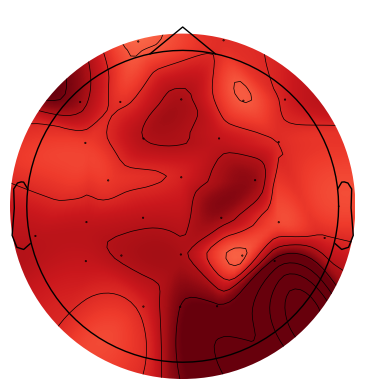

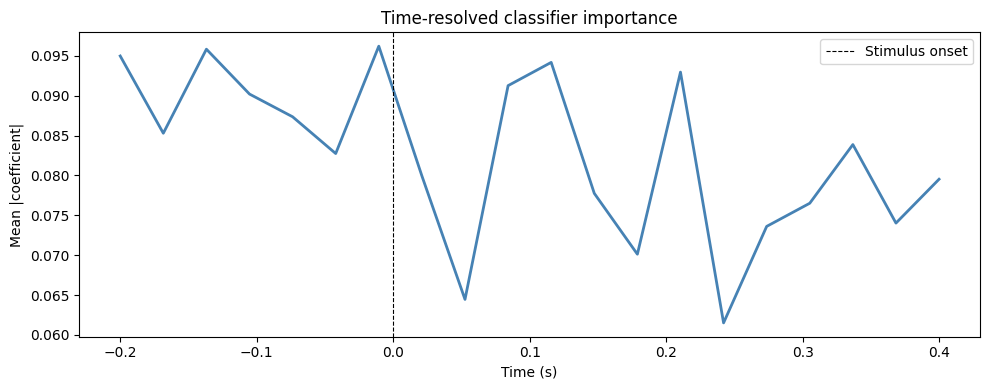

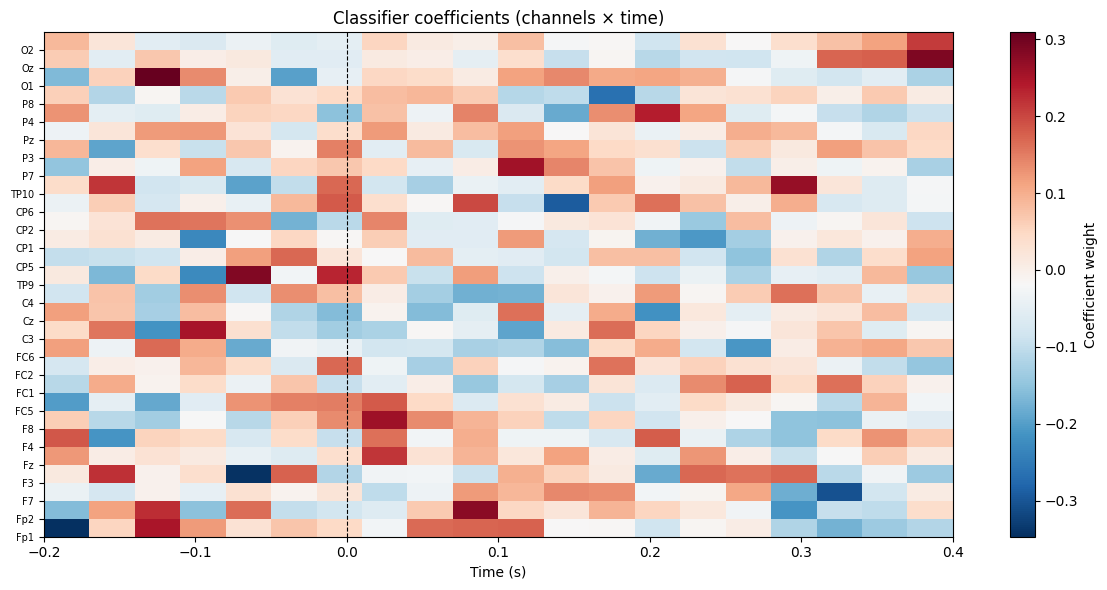

In [54]:
#code for what drove the classifier
import matplotlib.pyplot as plt

#fit classifier
clf.fit(X, y)

coef = clf.named_steps['lr'].coef_[0]

#reshape back
n_channels = epochs_speed.get_data().shape[1]
n_bins = 20

coef_2d = coef.reshape(n_channels, n_bins)

#channel importance
channel_importance = np.mean(np.abs(coef_2d), axis=1)

fig, ax = plt.subplots()
mne.viz.plot_topomap(channel_importance, epochs_speed.info, axes=ax, show=True)
ax.set_title('Mean |coefficient| across time (channel importance)')

#average time resolved
time_importance = np.mean(np.abs(coef_2d), axis=0)
time_bins = np.linspace(epochs_speed.tmin, epochs_speed.tmax, n_bins)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time_bins, time_importance, color='steelblue', linewidth=2)
ax.axvline(0, color='k', linestyle='--', linewidth=0.8, label='Stimulus onset')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Mean |coefficient|')
ax.set_title('Time-resolved classifier importance')
ax.legend()
plt.tight_layout()
plt.show()

#heatmap
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(coef_2d, aspect='auto', origin='upper', cmap='RdBu_r',
               extent=[epochs_speed.tmin, epochs_speed.tmax, 0, n_channels])
ax.set_yticks(range(n_channels))
ax.set_yticklabels(epochs_speed.ch_names, fontsize=7)
ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
ax.set_xlabel('Time (s)')
ax.set_title('Classifier coefficients (channels × time)')
plt.colorbar(im, ax=ax, label='Coefficient weight')
plt.tight_layout()
plt.show()